In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plt_config

In [9]:
try:
    x0 = np.load("../scripts/variables/x0_00.npy")
    inputs = np.load("../scripts/variables/inputs_00.npy")
    print("Loaded variables from previous runs")
except Exception:
    print("Run 00_Parameter_Distributions.py script")

Loaded variables from previous runs


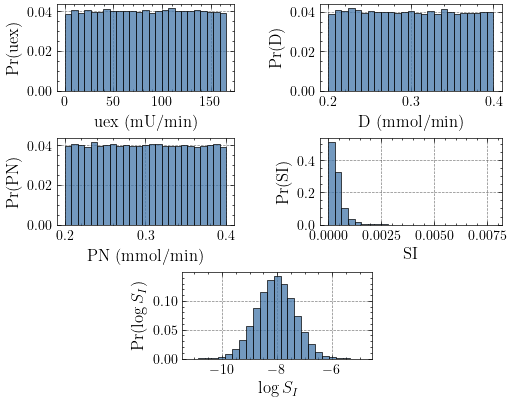

In [15]:
states = [
    "G (mmol/L)",
    "I (mU/L)",
    "Q (mU/L)",
    "P1 (mmol)",
    "P2 (mmol)",
    "P (mmol)",
    "uen (mU/min)",
]
states_short = ["G", "I", "Q", "P1", "P2", "P", "uen"]
input_labels = ["uex (mU/min)", "D (mmol/min)", "PN (mmol/min)", "SI"]
input_short = ["uex", "D", "PN", "SI"]

fig = plt.figure(figsize=(5.1,4))
gs = fig.add_gridspec(nrows=3, ncols=4, height_ratios=[1,1,1])
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[1, 0:2])
ax4 = fig.add_subplot(gs[1, 2:4])  
ax5 = fig.add_subplot(gs[2, 1:3])

for i, ax in enumerate([ax1, ax2, ax3, ax4], start=0):
    sns.histplot(data=inputs[i, :], bins=25, stat="probability", ax=ax)
    ax.set_xlabel(input_labels[i])
    ax.set_ylabel(f"Pr({input_short[i]})")

sns.histplot(data=np.log(inputs[-1, :]), bins=25, stat="probability", ax=ax5)
ax5.set_xlabel(r"$\log S_I$")
ax5.set_ylabel(r"Pr($\log S_I$)")
plt.show()
fig.savefig("figures/5_1.pdf", format="pdf")

In [11]:
print("Mean inputs and parameters: \n", np.mean(inputs, axis=1))
print("Range of inputs and parameters: \n", np.ptp(inputs, axis=1))
print("Min of inputs and parameters: \n", np.min(inputs, axis=1))
print("Max of inputs and parameters: \n", np.max(inputs, axis=1))

Mean inputs and parameters: 
 [8.30729907e+01 2.99606548e-01 2.99742832e-01 4.07961431e-04]
Range of inputs and parameters: 
 [1.65998412e+02 1.99998175e-01 1.99996204e-01 7.76766732e-03]
Min of inputs and parameters: 
 [6.83191287e-05 2.00000285e-01 2.00000552e-01 1.45529671e-05]
Max of inputs and parameters: 
 [1.65998480e+02 3.99998459e-01 3.99996756e-01 7.78222029e-03]


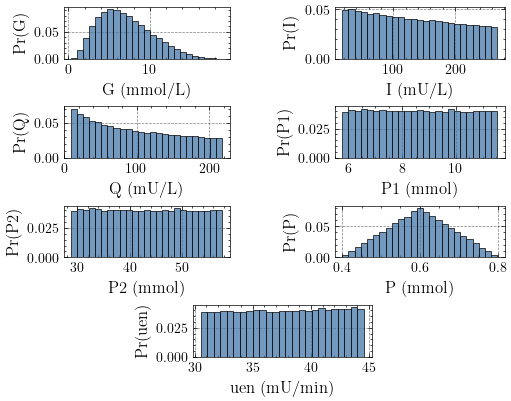

In [13]:
fig = plt.figure(figsize=(5.1,4))
gs = fig.add_gridspec(nrows=4, ncols=4, height_ratios=[1,1,1,1])

ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[1, 0:2])
ax4 = fig.add_subplot(gs[1, 2:4])  
ax5 = fig.add_subplot(gs[2, 0:2])
ax6 = fig.add_subplot(gs[2, 2:4]) 
ax7 = fig.add_subplot(gs[3, 1:3])

for i, ax in enumerate([ax1, ax2, ax3, ax4, ax5, ax6, ax7], start=0):
    sns.histplot(data=x0[i, :], bins=25, stat="probability", ax=ax)
    ax.set_xlabel(states[i])
    ax.set_ylabel(f"Pr({states_short[i]})")
plt.show()
fig.savefig("figures/5_2.pdf", format="pdf")

In [ ]:
print("Mean initial states: \n", np.mean(x0, axis=1))
print("Range of initial states: \n", np.ptp(x0, axis=1))
print("Min of initial states: \n", np.min(x0, axis=1))
print("Max of initial states: \n", np.max(x0, axis=1))
print("Initial Covariance: \n", np.diag(np.cov(x0, rowvar=True, bias=False)))

Mean initial states: 
 [  6.997877   133.28167042  98.31990277   8.64481763  43.22408814
   0.59934938  37.63751189]
Range of initial states: 
 [ 18.56181432 251.09477483 209.12743427   5.77072749  28.85363747
   0.39826257  13.97269285]
Min of initial states: 
 [ 0.34033436 17.41094761  9.28584643  5.77078838 28.85394189  0.4004591
 30.54923713]
Max of initial states: 
 [ 18.90214868 268.50572243 218.4132807   11.54151587  57.70757936
   0.79872167  44.52192999]
Initial Covariance: 
 [1.02278123e+01 5.21417490e+03 3.71232176e+03 2.78032838e+00
 6.95082095e+01 6.66200348e-03 1.62970774e+01]
